# NoteBook Store Sales - Time Series Forecasting

Romain SEBIRE - 125 009 460

## Carregamento dos dados ##

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

train = pd.read_csv('train.csv', parse_dates=['date'])
test = pd.read_csv('test.csv', parse_dates=['date'])
oil = pd.read_csv('oil.csv', parse_dates=['date'])
holidays = pd.read_csv('holidays_events.csv', parse_dates=['date'])
stores = pd.read_csv('stores.csv')
transactions = pd.read_csv('transactions.csv', parse_dates=['date'])

In [ ]:
# Definição do método de avaliação RMSLE
def rmsle(y_true, y_pred):
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2))

### Exibição das variáveis (features) e dos objetos de cada dataframe

In [3]:
import pandas as pd

# Dicionário de todos os DataFrames
datasets = {
    "train": train,
    "oil": oil,
    "holidays": holidays,
    "stores": stores,
    "transactions": transactions
}

# Percorra cada DataFrame
for name, df in datasets.items():
    print(f"\n--- {name.upper()} ---")
    print("Colonnes :", df.columns.tolist())
    for col in df.select_dtypes(include='object').columns:
        print(f"\n - {col} ({df[col].nunique()} objets) :")
        print(df[col].unique())



--- TRAIN ---
Colonnes : ['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion']

 - family (33 objets) :
['AUTOMOTIVE' 'BABY CARE' 'BEAUTY' 'BEVERAGES' 'BOOKS' 'BREAD/BAKERY'
 'CELEBRATION' 'CLEANING' 'DAIRY' 'DELI' 'EGGS' 'FROZEN FOODS' 'GROCERY I'
 'GROCERY II' 'HARDWARE' 'HOME AND KITCHEN I' 'HOME AND KITCHEN II'
 'HOME APPLIANCES' 'HOME CARE' 'LADIESWEAR' 'LAWN AND GARDEN' 'LINGERIE'
 'LIQUOR,WINE,BEER' 'MAGAZINES' 'MEATS' 'PERSONAL CARE' 'PET SUPPLIES'
 'PLAYERS AND ELECTRONICS' 'POULTRY' 'PREPARED FOODS' 'PRODUCE'
 'SCHOOL AND OFFICE SUPPLIES' 'SEAFOOD']

--- OIL ---
Colonnes : ['date', 'dcoilwtico']

--- HOLIDAYS ---
Colonnes : ['date', 'type', 'locale', 'locale_name', 'description', 'transferred']

 - type (6 objets) :
['Holiday' 'Transfer' 'Additional' 'Bridge' 'Work Day' 'Event']

 - locale (3 objets) :
['Local' 'Regional' 'National']

 - locale_name (24 objets) :
['Manta' 'Cotopaxi' 'Cuenca' 'Libertad' 'Riobamba' 'Puyo' 'Guaranda'
 'Imbabura' 'Latacunga' 'Machala' 'S

## Primeira parte: Primeiro preveja a venda total de uma loja ou de um produto em uma loja

In [4]:
# Concatenamos os DataFrames train e test para aplicar as mesmas transformações

train['is_test'] = 0
test['is_test'] = 1

df = pd.concat([train, test], ignore_index=True)

### Concatenação dos dataframes e adição de features úteis

In [5]:
df["day_of_week"] = df["date"].dt.dayofweek
df['day_of_year'] = df['date'].dt.dayofyear
df["day_of_month"] = df["date"].dt.day
df["month"] = df["date"].dt.month
df["year"] = df["date"].dt.year
df['rolling_mean_30'] = df.groupby(['store_nbr','family'])['sales'].transform(lambda x: x.rolling(30, min_periods=1).mean())


In [6]:
df = df.merge(
    stores[['store_nbr', 'city', 'state', 'type', 'cluster']],
    on='store_nbr',
    how='left'
)

df = df.merge(
    transactions[['store_nbr', 'date', 'transactions']],
    on=['store_nbr', 'date'],
    how='left'
)

### Análise exploratória dos dados (EDA)

#### Análise das distribuições

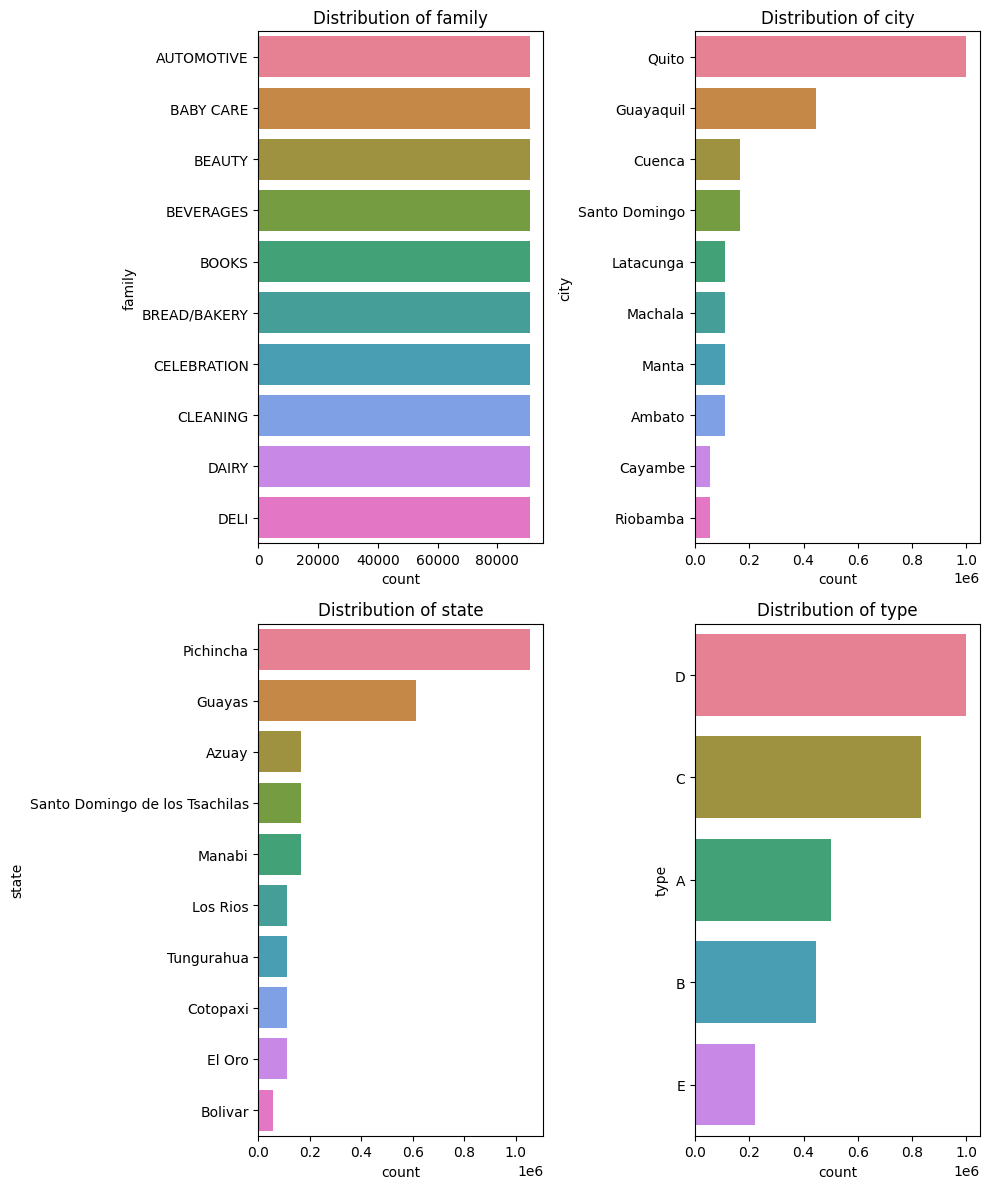

In [400]:
df_analysis = df[df['is_test'] == 0].drop(columns='is_test')
cat_vars = df_analysis.select_dtypes(include='object')

plt.figure(figsize=(10, 12))
for i, col in enumerate(cat_vars, 1):
    plt.subplot(2, 2, i)

    top_categories = df_analysis[col].value_counts().nlargest(10)
    top_cat_names = top_categories.index
    data = df_analysis[df_analysis[col].isin(top_cat_names)]
    palette = sns.color_palette("husl", len(top_cat_names))
    color_dict = dict(zip(top_cat_names, palette))

    sns.countplot(
        data=data,
        y=col,
        order=top_cat_names,
        hue=col,
        palette=color_dict,
        dodge=False,
        legend=False
    )

    plt.title(f'Distribution of {col}')
    plt.tight_layout()

plt.show()



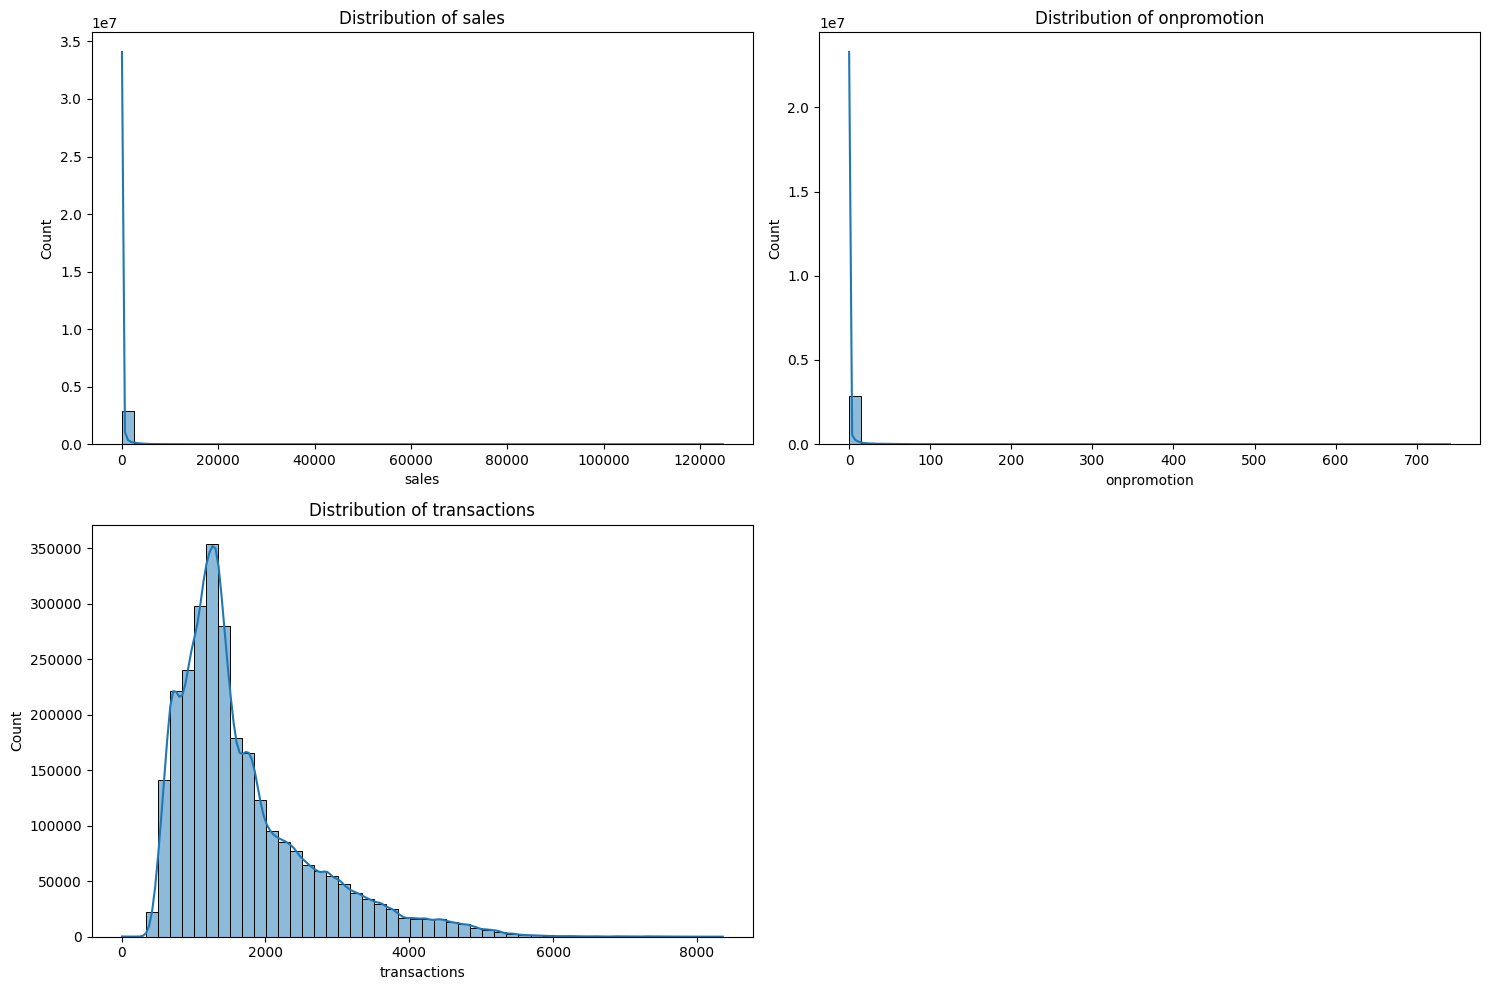

In [401]:
# Convert float16 to float32 to avoid NotImplementedError
df_analysis['onpromotion'] = df_analysis['onpromotion'].astype('float32')

# Define numerical variables
num_vars = ['sales', 'onpromotion', 'transactions']

# Plot distributions
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_vars, 1):
    plt.subplot(2, 2, i)
    
    # Filter out NaN values for the current column
    plot_data = df_analysis[col].dropna()
    
    # Use try-except to handle potential plotting issues
    try:
        sns.histplot(data=plot_data, kde=True, bins=50)
        plt.title(f'Distribution of {col}')
    except Exception as e:
        print(f"Could not plot {col}: {str(e)}")
        
plt.tight_layout()
plt.show()

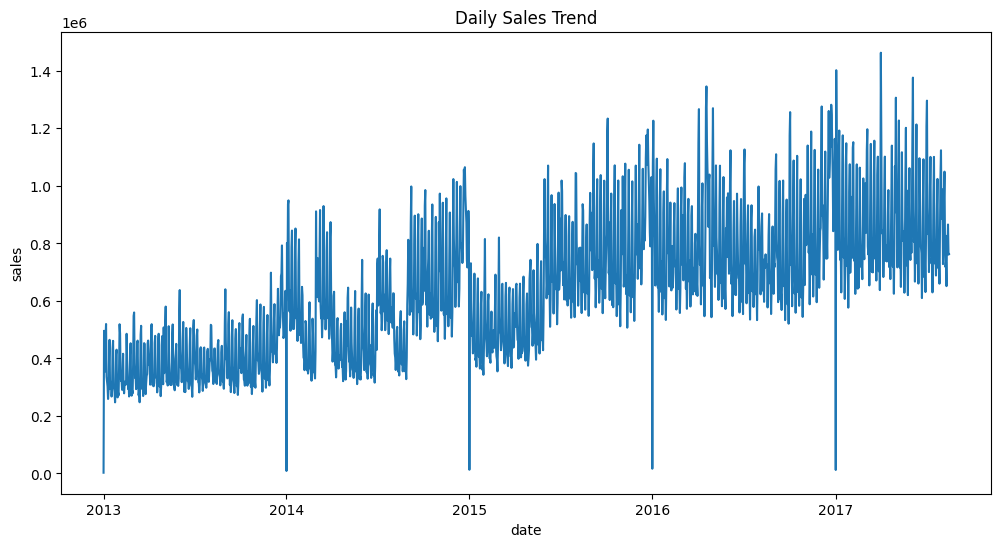

In [402]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_analysis.groupby('date')['sales'].sum().reset_index(), x='date', y='sales')
plt.title('Daily Sales Trend')
plt.show()

#### Visualização das relações com a variável alvo (Sales)

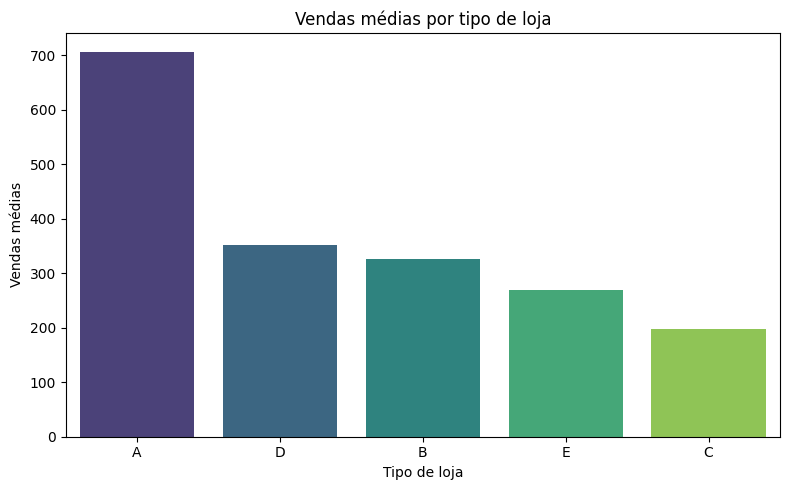

In [406]:
data = (
    df_analysis[["type", "sales"]]
    .groupby("type", as_index=False)
    .mean()
    .sort_values(by="sales", ascending=False)
)

# Barplot
plt.figure(figsize=(8, 5))
sns.barplot(data=data, x="type", y="sales", hue="type", palette="viridis", legend=False)

plt.title("Vendas médias por tipo de loja")
plt.xlabel("Tipo de loja")
plt.ylabel("Vendas médias")
plt.tight_layout()
plt.show()


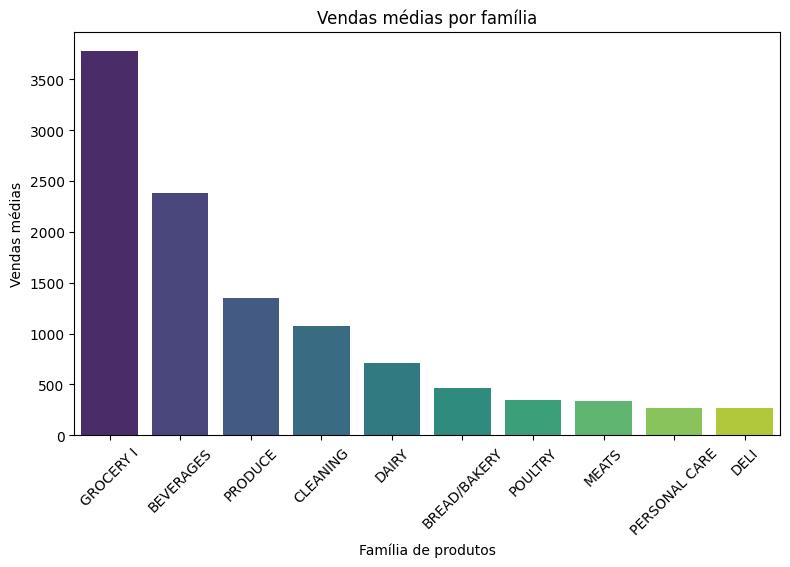

In [407]:
data = df_analysis[["family", "sales"]].groupby(["family"], as_index=False).mean().sort_values(by="sales", ascending=False).head(10)

# Barplot
plt.figure(figsize=(8, 5))
sns.barplot(data=data, x="family", y="sales", hue="family", palette="viridis", legend=False)

plt.title("Vendas médias por família")
plt.xlabel("Família de produtos")
plt.ylabel("Vendas médias")
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

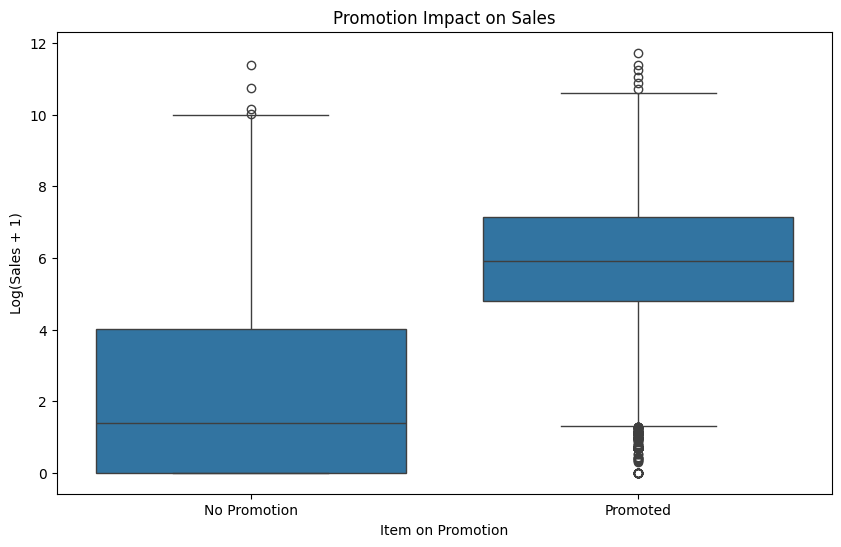

In [408]:
plt.figure(figsize=(10,6))
sns.boxplot(x=df_analysis["onpromotion"] > 0, 
            y=np.log1p(df["sales"]))
plt.title("Promotion Impact on Sales")
plt.xlabel("Item on Promotion")
plt.ylabel("Log(Sales + 1)")
plt.xticks([0,1], ["No Promotion", "Promoted"])
plt.show()


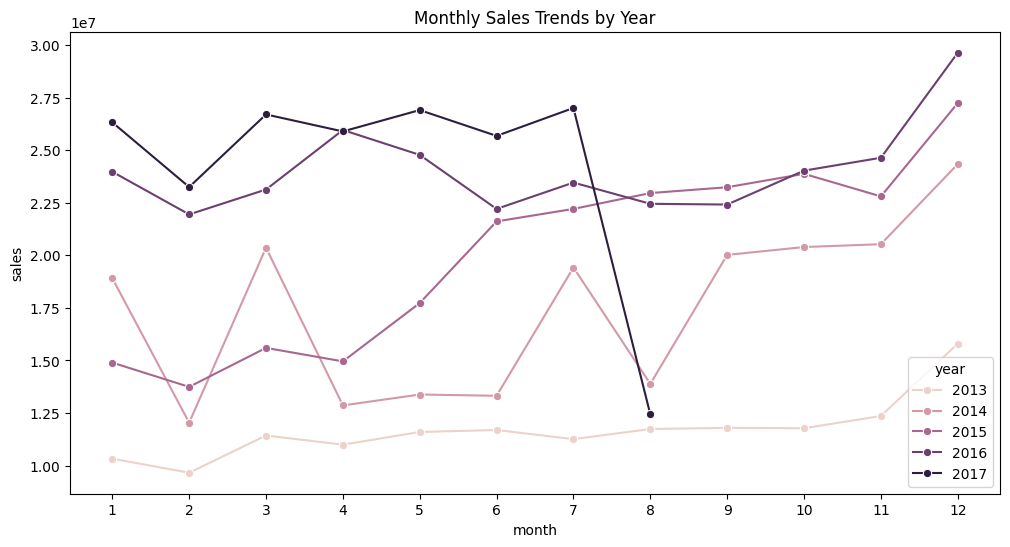

In [410]:
monthly_sales = df_analysis.groupby(["year", "month"])["sales"].sum().reset_index()
plt.figure(figsize=(12,6))
sns.lineplot(x="month", y="sales", hue="year", data=monthly_sales, marker="o")
plt.title("Monthly Sales Trends by Year")
plt.xticks(range(1,13))
plt.show()

In [113]:
print(df)

              id       date  store_nbr                      family     sales  \
0              0 2013-01-01          1                  AUTOMOTIVE     0.000   
1              1 2013-01-01          1                   BABY CARE     0.000   
2              2 2013-01-01          1                      BEAUTY     0.000   
3              3 2013-01-01          1                   BEVERAGES     0.000   
4              4 2013-01-01          1                       BOOKS     0.000   
...          ...        ...        ...                         ...       ...   
3000883  3000883 2017-08-15          9                     POULTRY   438.133   
3000884  3000884 2017-08-15          9              PREPARED FOODS   154.553   
3000885  3000885 2017-08-15          9                     PRODUCE  2419.729   
3000886  3000886 2017-08-15          9  SCHOOL AND OFFICE SUPPLIES   121.000   
3000887  3000887 2017-08-15          9                     SEAFOOD    16.000   

         onpromotion  day_of_week  day_

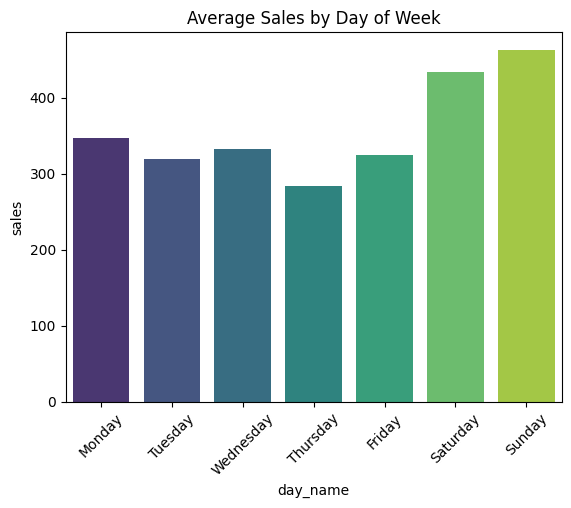

In [411]:
# Associar os números dos dias aos nomes
day_name_map = {
    0: "Monday", 1: "Tuesday", 2: "Wednesday", 3: "Thursday",
    4: "Friday", 5: "Saturday", 6: "Sunday"
}
# Substituir os números pelos nomes
dow_sales = df_analysis.groupby("day_of_week")["sales"].mean().reset_index()
dow_sales["day_name"] = dow_sales["day_of_week"].map(day_name_map)
sns.barplot(data=dow_sales, x="day_name", y="sales", hue="day_name", palette="viridis", legend=False)
plt.title("Average Sales by Day of Week")
plt.xticks(rotation=45)
plt.show()

### Busca e substituição dos valores ausentes

In [7]:
# Resumo dos valores ausentes
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100)

missing_summary = pd.concat([missing, missing_pct], axis=1)
missing_summary.columns = ['Total Missing', 'Percentage (%)']
missing_summary = missing_summary[missing_summary['Total Missing'] > 0]
missing_summary = missing_summary.sort_values(by='Percentage (%)', ascending=False)

print(missing_summary)


              Total Missing  Percentage (%)
transactions         274296        9.054466
sales                 28512        0.941176


Os valores ausentes em "sales" correspondem aos dados a serem previstos

Faltam 9% dos valores na tabela de transações, vamos substituir esses valores ausentes pela média das transações para cada loja.

In [8]:
store_trans_avg = df.groupby('store_nbr')['transactions'].mean().reset_index()
store_trans_avg.columns = ['store_nbr', 'store_mean_transactions']
df = df.merge(store_trans_avg, on='store_nbr', how='left')
df['transactions'] = df['transactions'].fillna(df['store_mean_transactions'])

### Treinamento de um modelo para prever as vendas totais de uma loja

Modelo RandomForestRegressor : RMSLE = 0.4956

In [415]:
store_id = 1
store_data = df[df['store_nbr'] == store_id].copy()

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Features
features = ['family', 'onpromotion', 'day_of_week', 'day_of_year', 'month', 'year','rolling_mean_30', 
            'city', 'state', 'type', 'cluster', 'transactions']

# Codificação das variáveis categóricas
for col in ['family', 'city', 'state', 'type']:
    store_data[col] = store_data[col].astype('category').cat.codes

store_train_data = store_data[store_data['is_test'] == 0].drop(columns='is_test')

# Ordenação dos dados por data
store_train_data = store_train_data.sort_values("date")

# Divisão manual
split_index = int(len(store_train_data) * 0.8)
train_data = store_train_data.iloc[:split_index]
val_data = store_train_data.iloc[split_index:]

X_train = train_data[features]
y_train = train_data["sales"]
X_val = val_data[features]
y_val = val_data["sales"]

# Treinar RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Previsão
y_pred = model.predict(X_val)
y_pred = np.maximum(0, y_pred)
score = rmsle(y_val, y_pred)
print(f"RMSLE: {score:.4f}")


RMSLE: 0.4956


Modelo LightGBM : RMSLE = 0.5674

In [420]:
store_id = 1
store_data = df[df['store_nbr'] == store_id].copy()

In [ ]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# Features
features = ['family', 'onpromotion', 'day_of_week', 'day_of_year', 'month', 'year','rolling_mean_30', 
            'city', 'state', 'type', 'cluster', 'transactions']

# Codificação das variáveis categóricas
for col in ['family', 'city', 'state', 'type']:
    store_data[col] = store_data[col].astype('category')

store_train_data = store_data[store_data['is_test'] == 0].drop(columns='is_test')

# Ordenação dos dados por data
store_train_data = store_train_data.sort_values("date")

# Divisão manual
split_index = int(len(store_train_data) * 0.8)
train_data = store_train_data.iloc[:split_index]
val_data = store_train_data.iloc[split_index:]

X_train = train_data[features]
y_train = train_data["sales"]
X_val = val_data[features]
y_val = val_data["sales"]

# Treinar LightGBM
model = lgb.LGBMRegressor(
    objective='regression',
    n_estimators=100,
    force_col_wise=True,
    random_state=42
)
model.fit(X_train, y_train)

# Previsão & RMSLE
y_pred = model.predict(X_val)
y_pred = np.maximum(0, y_pred)
score = rmsle(y_val, y_pred)
print(f"RMSLE: {score:.4f}")


[LightGBM] [Info] Total Bins 910
[LightGBM] [Info] Number of data points in the train set: 44457, number of used features: 8
[LightGBM] [Info] Start training from score 236.574843
RMSLE: 0.5674


Na sequência, usaremos o modelo RandomForestRegressor, que é mais eficiente

## Segunda parte: Acrescente a informação de feriados

### Data Analysis Feriados

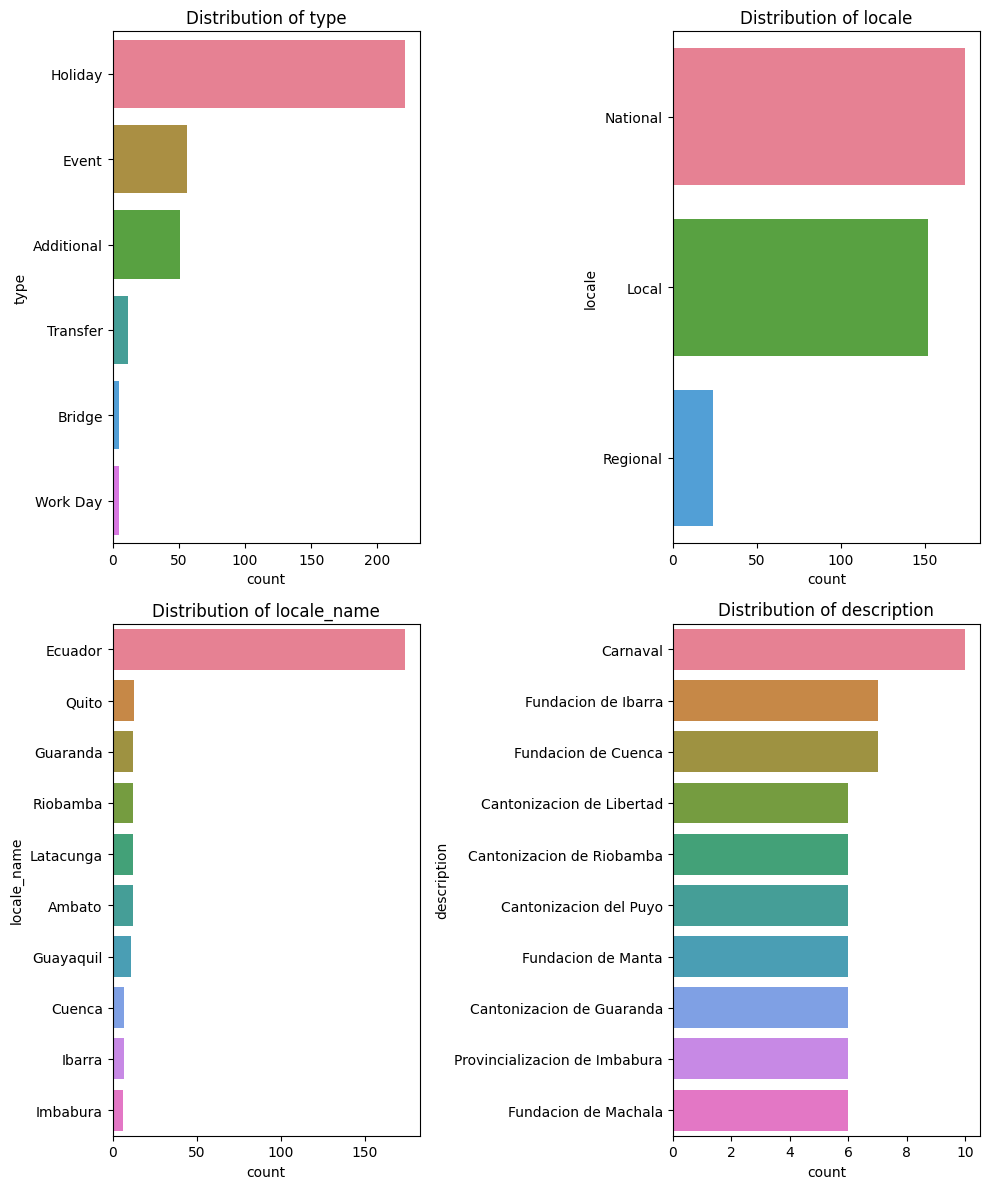

In [424]:
df_analysis = df[df['is_test'] == 0].drop(columns='is_test')
cat_vars = holidays.select_dtypes(include='object')

plt.figure(figsize=(10, 12))
for i, col in enumerate(cat_vars, 1):
    plt.subplot(2, 2, i)

    top_categories = holidays[col].value_counts().nlargest(10)
    top_cat_names = top_categories.index
    data = holidays[holidays[col].isin(top_cat_names)]
    palette = sns.color_palette("husl", len(top_cat_names))
    color_dict = dict(zip(top_cat_names, palette))

    sns.countplot(
        data=data,
        y=col,
        order=top_cat_names,
        hue=col,
        palette=color_dict,
        dodge=False,
        legend=False
    )

    plt.title(f'Distribution of {col}')
    plt.tight_layout()

plt.show()

### Acrescente a informação de feriados

In [9]:
# Filtrar os feriados não transferidos
holidays_filtered = holidays[(holidays['transferred'] == False) & (holidays['type'] != 'Work_day')]

# Feriados nacionais (válidos em todo lugar)
national_holidays = holidays_filtered[holidays_filtered['locale'] == 'National'][['date']].drop_duplicates()
national_holidays['is_national'] = 1

# Feriados regionais (por estado)
regional_holidays = holidays_filtered[holidays_filtered['locale'] == 'Regional'][['date', 'locale_name']].drop_duplicates()
regional_holidays['is_regional'] = 1
regional_holidays = regional_holidays.rename(columns={'locale_name': 'state'})

# Feriados locais (por cidade)
local_holidays = holidays_filtered[holidays_filtered['locale'] == 'Local'][['date', 'locale_name']].drop_duplicates()
local_holidays['is_local'] = 1
local_holidays = local_holidays.rename(columns={'locale_name': 'city'})

# Fusão dos 3 tipos de feriados no df
df = df.merge(national_holidays, on='date', how='left')
df = df.merge(regional_holidays, on=['date', 'state'], how='left')
df = df.merge(local_holidays, on=['date', 'city'], how='left')

# Preencher os NaN com 0 e criar o is_holiday final
df['is_national'] = df['is_national'].fillna(0)
df['is_regional'] = df['is_regional'].fillna(0)
df['is_local'] = df['is_local'].fillna(0)

df['is_holiday'] = ((df['is_national'] + df['is_regional'] + df['is_local']) > 0).astype(int)

df['holiday_type'] = (
    df['is_national'].astype(int).map({1: 'National'})
    .fillna(df['is_regional'].astype(int).map({1: 'Regional'}))
    .fillna(df['is_local'].astype(int).map({1: 'Local'}))
    .fillna('None')
)

df['holiday_type'] = df['holiday_type'].astype('category').cat.codes



### Treinamento de um modelo com a nova informação dos feriados

In [428]:
store_id = 1
store_data = df[df['store_nbr'] == store_id].copy()

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Features
features = ['family', 'onpromotion', 'day_of_week', 'day_of_year', 'month', 'year','rolling_mean_30',
             'city', 'state', 'type', 'cluster', 'transactions', 'holiday_type']

# Codificação das variáveis categóricas
for col in ['family', 'city', 'state', 'type']:
    df[col] = df[col].astype('category').cat.codes

store_train_data = store_data[store_data['is_test'] == 0].drop(columns='is_test')

# Ordenação dos dados por data
store_train_data = store_train_data.sort_values("date")

# Divisão manual
split_index = int(len(store_train_data) * 0.8)
train_data = store_train_data.iloc[:split_index]
val_data = store_train_data.iloc[split_index:]

X_train = train_data[features]
y_train = train_data["sales"]
X_val = val_data[features]
y_val = val_data["sales"]

# Treinar RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Previsão & RMSLE
y_pred = model.predict(X_val)
y_pred = np.maximum(0, y_pred)
score = rmsle(y_val, y_pred)
print(f"RMSLE: {score:.4f}")

RMSLE: 0.4931


RMSLE: 0.4931

## Terceira parte: Acrescente a informação do barril de petróleo

In [10]:
start = train.date.min().date()
end = test.date.max().date()

# Criar a série de datas completas entre o início e o fim
full_dates = pd.date_range(start, end)

# Identificar as datas ausentes nos dados de petróleo
missing_oil_dates = full_dates.difference(oil['date'])

# Número e porcentagem de datas ausentes
num_missing = len(missing_oil_dates)
total_dates = len(full_dates)
percent_missing = 100 * num_missing / total_dates

print("Análise dos dados de petróleo ausentes:")
print(f"- Total de datas esperadas : {total_dates}")
print(f"- Datas ausentes           : {num_missing}")
print(f"- Porcentagem ausente      : {percent_missing:.2f}%")


Análise dos dados de petróleo ausentes:
- Total de datas esperadas : 1704
- Datas ausentes           : 486
- Porcentagem ausente      : 28.52%


In [11]:
# Reconstituir uma série completa com as datas ausentes
oil_full = pd.DataFrame({"date": full_dates})
oil = oil_full.merge(oil, on="date", how="left").sort_values("date")


# Fusão com o dataframe principal
df = df.merge(oil, on="date", how="left")

In [12]:
# Interpolação linear
df['dcoilwtico'] = df['dcoilwtico'].interpolate(method='linear', limit_direction='both')

In [434]:
store_id = 1
store_data = df[df['store_nbr'] == store_id].copy()

In [435]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Features
features = ['family', 'onpromotion', 'day_of_week', 'day_of_year', 'month', 'year','rolling_mean_30',
             'city', 'state', 'type', 'cluster', 'transactions', 'holiday_type', 'dcoilwtico']

# Codificação das variáveis categóricas
for col in ['family', 'city', 'state', 'type']:
    df[col] = df[col].astype('category').cat.codes

store_train_data = store_data[store_data['is_test'] == 0].drop(columns='is_test')

# Ordenação dos dados por data
store_train_data = store_train_data.sort_values("date")

# Divisão manual
split_index = int(len(store_train_data) * 0.8)
train_data = store_train_data.iloc[:split_index]
val_data = store_train_data.iloc[split_index:]

X_train = train_data[features]
y_train = train_data["sales"]
X_val = val_data[features]
y_val = val_data["sales"]

# Treinar RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Previsão & RMSLE
y_pred = model.predict(X_val)
y_pred = np.maximum(0, y_pred)
score = rmsle(y_val, y_pred)
print(f"RMSLE: {score:.4f}")

RMSLE: 0.4737


RMSLE: 0.4737

## Quarta parte: Acrescente o pagamento dos funcionários públicos (de 15 em 15 dias)

In [13]:
# Adicionar indicadores de período de pagamento
df["is_payday"] = ((df.date.dt.day == 15) | 
                     (df.date.dt.is_month_end)).astype(int)

# Adicionar indicadores para os dias após o pagamento
df["is_day_after_payday"] = ((df.date.dt.day == 16) | 
                              (df.date.dt.day == 1)).astype(int)

df["is_two_days_after_payday"] = ((df.date.dt.day == 17) | 
                                   (df.date.dt.day == 2)).astype(int)

# Adicionar indicador da semana do pagamento (a semana inteira após o pagamento pode apresentar aumento nas vendas)
df["is_payday_week"] = ((df.date.dt.day >= 15) & (df.date.dt.day <= 21) | 
                          (df.date.dt.day >= 1) & (df.date.dt.day <= 7)).astype(int)

In [437]:
store_id = 1
store_data = df[df['store_nbr'] == store_id].copy()

In [438]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Features
features = ['family', 'onpromotion', 'day_of_week', 'day_of_year', 'month', 'year','rolling_mean_30',
             'city', 'state', 'type', 'cluster', 'transactions', 'holiday_type', 'dcoilwtico',
             'is_payday', 'is_day_after_payday', 'is_two_days_after_payday', 'is_payday_week']

# Codificação das variáveis categóricas
for col in ['family', 'city', 'state', 'type']:
    df[col] = df[col].astype('category').cat.codes

store_train_data = store_data[store_data['is_test'] == 0].drop(columns='is_test')

# Ordenação dos dados por data
store_train_data = store_train_data.sort_values("date")

# Divisão manual
split_index = int(len(store_train_data) * 0.8)
train_data = store_train_data.iloc[:split_index]
val_data = store_train_data.iloc[split_index:]

X_train = train_data[features]
y_train = train_data["sales"]
X_val = val_data[features]
y_val = val_data["sales"]

# Treinar RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Previsão & RMSLE
y_pred = model.predict(X_val)
y_pred = np.maximum(0, y_pred)
score = rmsle(y_val, y_pred)
print(f"RMSLE: {score:.4f}")

RMSLE: 0.4722


RMSLE: 0.4722

## Quinta parte: Ao final, faça a previsão para todas as lojas e produtos

In [ ]:
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.model_selection import train_test_split

# # Features
# features = ['family', 'onpromotion', 'day_of_week', 'day_of_year', 'month', 'year','rolling_mean_30',
#              'city', 'state', 'type', 'cluster', 'transactions', 'holiday_type', 'dcoilwtico',
#              'is_payday', 'is_day_after_payday', 'is_two_days_after_payday', 'is_payday_week']

# # Codificação das variáveis categóricas
# for col in ['family', 'city', 'state', 'type']:
#     df[col] = df[col].astype('category').cat.codes

# df_train = df[df['is_test'] == 0].drop(columns='is_test')

# # Ordenação dos dados por data
# df_train = df_train.sort_values("date")

# X_train = df_train[features]
# y_train = df_train["sales"]

# # Treinar RandomForestRegressor
# model = RandomForestRegressor(n_estimators=100, random_state=42)
# model.fit(X_train, y_train)

MemoryError: could not allocate 268435456 bytes

O modelo RandomForestRegressor é muito custoso e lento, após várias tentativas, gera um erro de memória insuficiente. Portanto, vou voltar ao modelo LGBMRegressor, um pouco menos performático, mas mais econômico.

In [14]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split

# Features
features = ['family', 'onpromotion', 'day_of_week', 'day_of_year', 'month', 'year','rolling_mean_30',
             'city', 'state', 'type', 'cluster', 'transactions', 'holiday_type', 'dcoilwtico',
             'is_payday', 'is_day_after_payday', 'is_two_days_after_payday', 'is_payday_week']

# Codificação das variáveis categóricas
for col in ['family', 'city', 'state', 'type']:
    df[col] = df[col].astype('category')

df_train = df[df['is_test'] == 0].drop(columns='is_test')

# Ordenação dos dados por data
df_train = df_train.sort_values("date")

X_train = df_train[features]
y_train = df_train["sales"]

# Treinar LightGBM
model = lgb.LGBMRegressor(
    objective='regression',
    n_estimators=100,
    force_col_wise=True,
    random_state=42
)
model.fit(X_train, y_train)

[LightGBM] [Info] Total Bins 1357
[LightGBM] [Info] Number of data points in the train set: 3000888, number of used features: 18
[LightGBM] [Info] Start training from score 357.775749


LGBMRegressor(force_col_wise=True, objective='regression', random_state=42)

In [ ]:
df_test = df[df['is_test'] == 1].drop(columns='is_test')

# Previsão
X_test = df_test[features]
y_pred = model.predict(X_test)

# Forçar os valores positivos
y_pred = np.maximum(0, y_pred)

df_test['sales'] = y_pred

# Preparar a submissão
df_submission = df_test[['id', 'sales']]
print(df_submission.head())

submission_file_path = 'submission.csv'
df_submission.to_csv(submission_file_path, index=False)


              id        sales
3000888  3000888     4.939010
3000889  3000889     4.386570
3000890  3000890    14.684427
3000891  3000891  2047.896911
3000892  3000892     4.386570


## Resultados no Kaggle

Public score : 0.69857